<a href="https://colab.research.google.com/github/Rajeeb321123/Pytorch/blob/master/08_NLP_pytroch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to NLP Fundamental in Pytorch

NLP has the goal of deriving out of natural language ( could be sequence text or speech)

Another common term for NLP problems is sequence problem (seq2seq).

In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
%%capture
!pip install -q "tqdm>=4.64.1"
!pip install mermaid-py
!pip install torchinfo
!pip install psutil

In [ ]:
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import clear_output

# Import torchvision
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import LambdaLR

# Check versions
# Note: your PyTorch version shouldn't be lower than 1.10.0 and torchvision version shouldn't be lower than 0.11
print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")

if torch.cuda.is_available():
  device = "cuda"
else:
  device = "cpu"
device

PyTorch version: 2.5.1+cu124
torchvision version: 0.20.1+cu124


'cpu'

# Get Data

In [ ]:
!git clone https://github.com/Franck-Dernoncourt/pubmed-rct
!ls pubmed-rct

Cloning into 'pubmed-rct'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 39 (delta 8), reused 5 (delta 5), pack-reused 25 (from 1)
Receiving objects: 100% (39/39), 177.08 MiB | 22.53 MiB/s, done.
Resolving deltas: 100% (15/15), done.
Updating files: 100% (13/13), done.
PubMed_200k_RCT				       PubMed_20k_RCT_numbers_replaced_with_at_sign
PubMed_200k_RCT_numbers_replaced_with_at_sign  README.md
PubMed_20k_RCT


In [ ]:
# Check what files are in the PubMed_20k Dataset
!ls pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/

dev.txt  test.txt  train.txt


In [ ]:
# Start ou experiment using the 20k dataset with numbers replaced by "@" sign
data_dir = "/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/"

In [ ]:
import os
os.listdir(data_dir)

['dev.txt', 'train.txt', 'test.txt']

In [ ]:
# Check all of the filename in the target directory
import os
filenames = [data_dir + filename for filename in os.listdir(data_dir)]
filenames

['/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/dev.txt',
 '/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/train.txt',
 '/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/test.txt']

#Visualize Data

In [ ]:
# Create a function to read the line of a document
def get_lines(filename):
  """
  Reads filename (a text filename) and returns the lines of text as a lists.

  Args:
    filename:  a string containing the target filepath.

  Returns:
    A List of strings with one string per line from the target filename.
  """

  # with is simialr to try/finally
  with open(filename, "r") as f:
    return f.readlines()

In [ ]:
# Let's read in the training lines
train_lines = get_lines(data_dir + "train.txt") # read the line for training file
train_lines[:28]

['###24293578\n',
 'OBJECTIVE\tTo investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .\n',
 'METHODS\tA total of @ patients with primary knee OA were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .\n',
 'METHODS\tOutcome measures included pain reduction and improvement in function scores and systemic inflammation markers .\n',
 'METHODS\tPain was assessed using the visual analog pain scale ( @-@ mm ) .\n',
 'METHODS\tSecondary outcome measures included the Western Ontario and McMaster Universities Osteoarthritis Index scores , patient global assessment ( PGA ) of the severity of knee OA , and @-min walk distance ( @MWD ) .\n',
 'METHODS\tSerum levels of interleukin @ ( IL-@ ) , IL-@ , tumor necrosis factor ( TNF ) - , and 

In [ ]:
len(train_lines)

210040

In [ ]:
train_lines[20]

'METHODS\tAttentional biases for high caloric foods were measured by eye tracking during a visual probe task with pictorial food and neutral stimuli .\n'

In [ ]:
"abc\ncd".replace("\n", "")

'abccd'

Let's think about how we want our data to look.

How I think our data would be represented?

```
[
  {
    'line_number': 0,
    'target': 'BACKGROUND',
    'text': Emotional eating is associated with overeating and the development of obesity .\n',
    'total_lines': 11
  },
  ...
]
```

In [ ]:
len("tom\ttom".split("\t"))

2

In [ ]:
train_lines[1]

'OBJECTIVE\tTo investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .\n'

In [ ]:
# very important to look at the train_lines in above to visualize the data and how it is formatted
def preprocess_text_with_line_numbers(filename):
  """
  Return a list of dictionaries of abstract line data.

  Takes in filename, reads it contents and sort through each line,
  extracting things like the target label, the text of sentence,
  how many sentences are in the current abstract and what sentence number the target line is.
  """

  input_lines = get_lines(filename) # get all lines from filename

  # abstract are separated by '/n' and '###24293578\n'
  abstract_lines = "" # create an empty abstract
  abstract_samples = [] # create and empty list of abstracts

  # Loop through each line in the target file
  for line in input_lines:

    # at the start of each abstract
    if line.startswith("###"): # check to see if the line is an ID line
      abstract_id = line
      abstract_lines = "" # reset the abstract string if the line is an ID line


    # the end of each abstract: we know we have '\n' at the end of each abstract (1 abstract: whole collection of background, methond, objective...)
    # elif line == '\n'
    elif line.isspace(): # means is it '\n' # check if the line is new line. if we reach end of the each line_number
      # now we again split line for each background, objective...
      # return list of each list
      abstract_line_split = abstract_lines.splitlines() # split abstract into separate lines or it won string like ['hello i am Rajeeb', "todayis good day']"

      # Iterate thorugh each line in a single abstract and count them at the same time.
      for abstract_line_number, abstract_line in enumerate(abstract_line_split):
        line_data = {} # create an empty dictionary for each line
        target_text_split = abstract_line.split("\t") # split target label from text eg: [objective\tHello] ---> [objective, Hello]
        line_data["target"] = target_text_split[0] # get target label
        line_data["text"] = target_text_split[1].lower() # get target text and lower it # probably no need for lower for do it anyway.
        line_data["line_number"] = abstract_line_number # what number line does the line appear in the abstract
        line_data["total_lines"]  = len(abstract_line_split)-1 # how many total lines are there in target abstract (start from 0 i.e - 1)
        abstract_samples.append(line_data) # add line data to abstract sample list

    # if we are in BACKGROUND, or OBJECTIVE, OR REUSLTS .... (not at the start of abstract (###) or end ('\n') )
    else: # if the above condition aren't fulfilled the line contains a labelled sentence
      abstract_lines += line # adding whole element to abstract_lines so it can be formatted later in above elif condition when we reach the end of abstrac

  return abstract_samples


In [ ]:
# Get data from file and preprocess it
%%time
train_samples = preprocess_text_with_line_numbers(data_dir + "train.txt")
val_samples = preprocess_text_with_line_numbers(data_dir + "dev.txt") # another txt file
test_samples = preprocess_text_with_line_numbers(data_dir + "test.txt")

len(train_samples), len(val_samples), len(test_samples)

CPU times: user 685 ms, sys: 146 ms, total: 830 ms
Wall time: 1.86 s


(180040, 30212, 30135)

In [ ]:
# Check the first abstract of our training data
train_samples[:14]

[{'target': 'OBJECTIVE',
  'text': 'to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
  'line_number': 0,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
  'line_number': 1,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
  'line_number': 2,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
  'line_number': 3,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'secondary outcome measures included the western ontari

In [ ]:
import pandas as pd

train_df = pd.DataFrame(train_samples)
val_df = pd.DataFrame(val_samples)
test_df = pd.DataFrame(test_samples)
train_df.head(14)


,target,text,line_number,total_lines
0,OBJECTIVE,to investigate the efficacy of @ weeks of dail...,0,11
1,METHODS,a total of @ patients with primary knee oa wer...,1,11
2,METHODS,outcome measures included pain reduction and i...,2,11
3,METHODS,pain was assessed using the visual analog pain...,3,11
4,METHODS,secondary outcome measures included the wester...,4,11
5,METHODS,"serum levels of interleukin @ ( il-@ ) , il-@ ...",5,11
6,RESULTS,there was a clinically relevant reduction in t...,6,11
7,RESULTS,the mean difference between treatment arms ( @...,7,11
8,RESULTS,"further , there was a clinically relevant redu...",8,11
9,RESULTS,these differences remained significant at @ we...,9,11


In [ ]:
# Distribution of labels in training data
train_df.target.value_counts()

,count
target,
METHODS,59353
RESULTS,57953
CONCLUSIONS,27168
BACKGROUND,21727
OBJECTIVE,13839


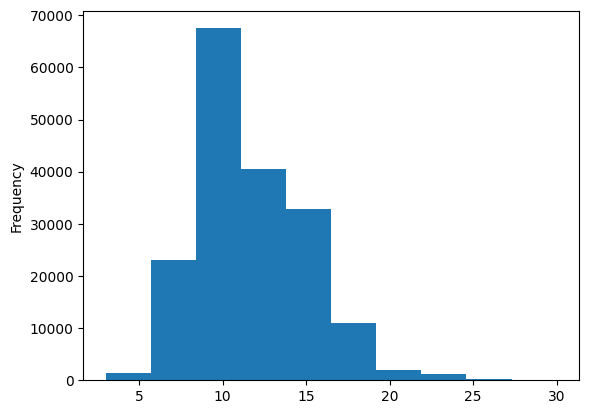

In [ ]:
# Let's check the length of different lines
train_df.total_lines.plot.hist();

In [ ]:
# Convert abstract text lines into lists
train_sentences = train_df["text"].tolist()
val_sentences = val_df["text"].tolist()
test_sentences = test_df["text"].tolist()
len(train_sentences), len(val_sentences), len(test_sentences)

(180040, 30212, 30135)

In [ ]:
# View the 10 lines of training sentences
train_sentences[:10]

['to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
 'secondary outcome measures included the western ontario and mcmaster universities osteoarthritis index scores , patient global assessment ( pga ) of the severity of knee oa , and @-min walk distance ( @mwd ) .',
 'serum levels of interleukin @ ( il-@ ) , il-@ , tumor necrosis factor ( tnf ) - , and high-sensitivity c-reactive protein ( hscrp ) were measured .',
 'there was a clinic

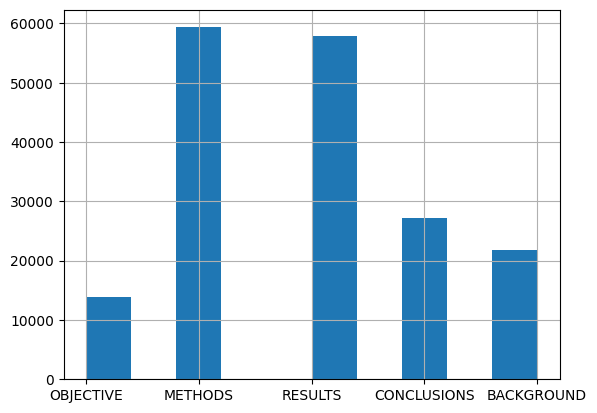

In [ ]:
train_df["target"].hist();

In [ ]:
train_df["target"].to_numpy()

array(['OBJECTIVE', 'METHODS', 'METHODS', ..., 'RESULTS', 'CONCLUSIONS',
       'CONCLUSIONS'], dtype=object)

# Data Preprocessing

### One Hot Encoder

In [ ]:
# import torch

# # Sample array
# categories = train_df["target"].to_numpy()

# # Convert the array to a tensor of unique category indices
# category_to_index = {category: idx for idx, category in enumerate(set(categories))}
# indices = torch.tensor([category_to_index[category] for category in categories])

# # One-hot encode the indices
# one_hot_encoded = torch.nn.functional.one_hot(indices, num_classes=len(category_to_index))

# print(category_to_index)
# print(one_hot_encoded[:10])


In [ ]:
train_df["target"].to_numpy().reshape(-1, 1)

array([['OBJECTIVE'],
       ['METHODS'],
       ['METHODS'],
       ...,
       ['RESULTS'],
       ['CONCLUSIONS'],
       ['CONCLUSIONS']], dtype=object)

In [ ]:
# One hot encode labels of train data
from sklearn.preprocessing import OneHotEncoder
one_hot_encoder = OneHotEncoder(sparse_output=False) # we want non-sparse matrix as tensorflow is incompatible with sparse matrix
train_labels_one_hot = one_hot_encoder.fit_transform(train_df["target"].to_numpy().reshape(-1, 1))
val_labels_one_hot = one_hot_encoder.transform(val_df["target"].to_numpy().reshape(-1, 1))
test_labels_one_hot = one_hot_encoder.transform(test_df["target"].to_numpy().reshape(-1, 1))

# Check out our one hot encoded labels
train_labels_one_hot[:10], val_labels_one_hot[:10], test_labels_one_hot[:10]

(array([[0., 0., 0., 1., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.]]),
 array([[1., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.],
        [0., 1., 0., 0., 0.]]),
 array([[1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.],
        [0., 1., 0., 0., 0.],
        [0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0.]]))

### Label Encoder

In [ ]:
# Extract label {"target" columns} and encode them into integers
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
train_labels_encoded = label_encoder.fit_transform(train_df["target"].to_numpy())
val_labels_encoded = label_encoder.transform(val_df["target"].to_numpy())
test_label_encoded = label_encoder.transform(test_df["target"].to_numpy())

# Check out training labels
train_labels_encoded

array([3, 2, 2, ..., 4, 1, 1])

# Model_0: Navie Bayes and Tf-IDF vectorizer

Bayes' Theorem:
$$
P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}
$$

where:

- $P(A|B)$: Posterior probability of event $A$ given that event $B$ has occurred.
- $P(B|A)$: Likelihood of event $B$ given that event $A$ has occurred.
- $P(A)$: Prior probability of event $A$.
- $P(B)$: Prior probability of event $B$.

- **Posterior Probability ($P(A|B)$)**: Probability of event $A$ occurring given that event $B$ has occurred.
- **Likelihood ($P(B|A)$)**: Probability of observing event $B$ given that $A$ is true.
- **Prior Probability ($P(A)$)**: Initial belief about the probability of event $A$ before any evidence $B$ is taken into account.
- **Evidence ($P(B)$)**: Total probability of observing event $B$, summed over all possible occurrences.

Bayes' Theorem helps us update our initial beliefs (priors) based on new evidence (likelihoods) to obtain a more accurate posterior probability.


Naïve Bayes Formula:
$$
P(C_k | x_1, x_2, \ldots, x_n) = \frac{P(C_k) \cdot P(x_1 | C_k) \cdot P(x_2 | C_k) \cdot \ldots \cdot P(x_n | C_k)}{P(x_1, x_2, \ldots, x_n)}
$$

where:

$$
P(C_k | x_1, x_2, \ldots, x_n) \propto P(C_k) \cdot \prod_{i=1}^{n} P(x_i | C_k)
$$

- $P(C_k)$: Prior probability of class $C_k$.
- $P(x_i | C_k)$: Likelihood of feature $x_i$ given class $C_k$.
- $P(x_1, x_2, \ldots, x_n)$: Marginal probability of the predictors (a normalizing constant for all classes).


`Multinomial Naïve Bayes Formula`

Given a document $d$ represented by the vector of word counts $\mathbf{x} = (x_1, x_2, \ldots, x_n)$ and a class $C_k$:

$$
P(C_k | \mathbf{x}) = \frac{P(C_k) \cdot P(x_1 | C_k) \cdot P(x_2 | C_k) \cdot \ldots \cdot P(x_n | C_k)}{P(\mathbf{x})}
$$

where:

- $P(C_k)$: Prior probability of class $C_k$.
- $P(x_i | C_k)$: Likelihood of feature $x_i$ given class $C_k$.
- $P(\mathbf{x})$: Prior probability of the feature vector $\mathbf{x}$.

---

`Simplified Formula for Classification of Multinomial NB`

Since $P(\mathbf{x})$ is constant for all classes:

$$
P(C_k | \mathbf{x}) \propto P(C_k) \cdot \prod_{i=1}^{n} P(x_i | C_k)
$$

---

` Explanation of Multinomial NB`

Multinomial Naïve Bayes is suitable for discrete data such as word counts in text classification. It uses the multinomial distribution to model the distribution of features and assumes that the features are conditionally independent given the class label.


### Term Frequency-Inverse Document Frequency (TF-IDF)

$$
\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)
$$

where:

$$
\text{TF}(t, d) = \frac{\text{Number of times term } t \text{ appears in document } d}{\text{Total number of terms in document } d}
$$

$$
\text{IDF}(t) = \log \left( \frac{1 + N}{1 + \text{DF}(t)} \right)
$$

- $t$: Term (word)
- $d$: Document
- $N$: Total number of documents
- $\text{DF}(t)$: Number of documents containing the term $t$


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer #Convert a collection of raw documents to a matrix of TF-IDF features or vectors.
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

# Create tokenization and modelling Pipeline
model_0 = Pipeline([
    # Tuple
    ("tfidf", TfidfVectorizer()), # Convert words to number using tfidf
    ("clf", MultinomialNB()) # model the text
])

# Fit the pipeline to the training data
model_0.fit(X=train_sentences, y=train_labels_encoded) # multinomialNB doesnot support one hot encoded, just label encoder

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('clf', MultinomialNB())])

In [ ]:
baseline_score = model_0.score(val_sentences, val_labels_encoded)
print(f"Our baseline model achieves an accuracy of: {baseline_score*100:.2f}%")

Our baseline model achieves an accuracy of: 72.18%


In [ ]:
# function to show true and predicted value in table
def create_table(true_labels, predicted_labels):
  """
  Creates a pandas DataFrame with columns for true labels, predicted labels, and whether they match.

  Args:
      true_labels (list): List of true labels.
      predicted_labels (list): List of predicted labels.

  Returns:
      pandas.DataFrame: DataFrame containing true labels,
      predicted labels, and a boolean column indicating if they match.
  """

  df = pd.DataFrame({
      "true_label": true_labels,
      "predicted_label": predicted_labels,
      "match": true_labels == predicted_labels
  })

  return df

In [ ]:
# Make predictions using our baseline model
baseline_preds = model_0.predict(val_sentences)
baseline_preds, val_labels_encoded

(array([4, 1, 3, ..., 4, 4, 1]), array([0, 0, 3, ..., 4, 1, 1]))

In [ ]:
# Get class names and number of classes from label encoder instances
num_classes = len(label_encoder.classes_)
class_names = label_encoder.classes_
print(f"num_classes:{num_classes} and class_names: {class_names}")
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(label_mapping)

num_classes:5 and class_names: ['BACKGROUND' 'CONCLUSIONS' 'METHODS' 'OBJECTIVE' 'RESULTS']
{'BACKGROUND': 0, 'CONCLUSIONS': 1, 'METHODS': 2, 'OBJECTIVE': 3, 'RESULTS': 4}


In [ ]:
create_table(val_labels_encoded, baseline_preds).head()

,true_label,predicted_label,match
0,0,4,False
1,0,1,False
2,3,3,True
3,2,2,True
4,2,2,True


In [ ]:
import torch
import torch.nn as nn

# Vocabulary size and embedding dimension
vocab_size = 10000
embedding_dim = 300

# Define the embedding layer
embedding = nn.Embedding(vocab_size, embedding_dim)

# Example input (batch of word indices)
input_indices = torch.tensor([5])

# Get the embeddings for the input indices
embedded = embedding(input_indices)

print("Shape of the embedding matrix:", embedding.weight.shape)
print("Shape of the embedded input:", embedded.shape)


Shape of the embedding matrix: torch.Size([10000, 300])
Shape of the embedded input: torch.Size([1, 300])


# Learning embedding layer in Neural network

## Simplest embedding

In [ ]:
import torch
import torch.nn as nn

class CustomEmbedding(nn.Module):
    def __init__(self, num_embeddings, embedding_dim):
        """
        Custom implementation of an embedding layer.

        Args:
            num_embeddings (int): Size of the dictionary of embeddings (vocabulary size).
            embedding_dim (int): The size of each embedding vector.
        """
        super(CustomEmbedding, self).__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim

        # Initialize the embedding weights randomly
        self.weight = nn.Parameter(torch.randn(num_embeddings, embedding_dim))

    def forward(self, input_ids):
        """
        Forward pass for the embedding layer.

        Args:
            input_ids (torch.Tensor): Tensor of indices to look up in the embedding table.
                                     Shape: (batch_size, seq_len) or (seq_len,).

        Returns:
            torch.Tensor: Tensor of embeddings corresponding to the input indices.
                         Shape: (batch_size, seq_len, embedding_dim) or (seq_len, embedding_dim).
        """
        # Look up embeddings for the input indices
        return self.weight[input_ids]

# Example usage
if __name__ == "__main__":
    # Define parameters
    vocab_size = 10  # Number of words in the vocabulary
    embedding_dim = 5  # Dimension of each embedding vector
    batch_size = 2
    seq_len = 3

    # Create a custom embedding layer
    custom_embedding = CustomEmbedding(num_embeddings=vocab_size, embedding_dim=embedding_dim)

    # Create input tensor (indices)
    input_ids = torch.tensor([[1, 2, 4], [0, 3, 9]])  # Shape: (batch_size, seq_len)

    # Forward pass
    embeddings = custom_embedding(input_ids)
    print("Input IDs:\n", input_ids)
    print("Embeddings:\n", embeddings)

Input IDs:
 tensor([[1, 2, 4],
        [0, 3, 9]])
Embeddings:
 tensor([[[ 0.8841,  0.2158,  0.9716,  1.0074, -0.1318],
         [-0.0682, -0.5498,  0.8141,  1.4693, -0.1168],
         [-0.4945,  1.9058,  1.5834, -1.9117, -0.4450]],

        [[-2.0951, -0.1727,  0.8738, -0.3310,  0.2838],
         [-0.0962, -1.0197, -0.9410,  0.1081, -0.0294],
         [ 0.7818,  0.0274,  0.7741,  0.0077, -0.8766]]],
       grad_fn=<IndexBackward0>)


## High level Emebedding model in Python instead of C++/ Cuda

Embeddings:
 tensor([[[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
         [ 0.7988,  0.8778,  1.3247,  0.5557,  0.7264],
         [ 0.4432,  1.2291,  1.1268,  0.9214, -0.4176]],

        [[-0.1620, -0.7091,  1.2028, -0.6621, -0.9345],
         [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
         [-1.8796,  0.2774, -0.6164, -0.0272, -0.0972]]])
Norms:
 tensor([[0.0000, 2.0000, 2.0000],
        [1.8131, 0.0000, 2.0000]])


In [ ]:
input = torch.randint(0,10,size=(2,3), dtype=torch.int32)
input_flat = input.reshape(-1)
print(input_flat)

weight = nn.Parameter(torch.randint(0,10, size=(10, 5), dtype = torch.float32))

embeddings_flat = torch.index_select(
            weight ,
            dim=0,
            index=input_flat
        )

print(weight)
print(embeddings_flat)

# Step 3: Reshape to original input shape + embedding dimension
output = embeddings_flat.reshape(*input.shape, 5)
print(output)

tensor([4, 9, 7, 3, 0, 8], dtype=torch.int32)
Parameter containing:
tensor([[8., 8., 4., 9., 5.],
        [8., 4., 8., 8., 2.],
        [4., 7., 6., 6., 0.],
        [5., 7., 5., 2., 1.],
        [0., 9., 1., 5., 8.],
        [7., 7., 6., 1., 1.],
        [4., 4., 5., 1., 3.],
        [1., 3., 7., 0., 4.],
        [4., 2., 7., 1., 3.],
        [5., 6., 7., 0., 2.]], requires_grad=True)
tensor([[0., 9., 1., 5., 8.],
        [5., 6., 7., 0., 2.],
        [1., 3., 7., 0., 4.],
        [5., 7., 5., 2., 1.],
        [8., 8., 4., 9., 5.],
        [4., 2., 7., 1., 3.]], grad_fn=<IndexSelectBackward0>)
tensor([[[0., 9., 1., 5., 8.],
         [5., 6., 7., 0., 2.],
         [1., 3., 7., 0., 4.]],

        [[5., 7., 5., 2., 1.],
         [8., 8., 4., 9., 5.],
         [4., 2., 7., 1., 3.]]], grad_fn=<ViewBackward0>)


## Word2Vec


Word2Vec is a neural network model used for natural language processing tasks to generate word embeddings—dense vector representations of words. Developed by Google, this model captures semantic meanings and relationships between words by training on large text corpora. It comes in two main architectures: Continuous Bag of Words (CBOW) and Skip-Gram. CBOW predicts a target word from its surrounding context, whereas Skip-Gram predicts context words given a target word. These embeddings can then be used in various NLP applications, such as text classification, clustering, and recommendation systems, where similar words are positioned closer in the vector space, reflecting their contextual similarity.

### SkimGram




#### SkimGram - Simple method ( No applicable)
https://www.youtube.com/watch?v=jKUwzgzdz3U&t=115s

**Skip-Gram** is a variant of the Word2Vec model used to learn word embeddings. Unlike the Continuous Bag of Words (CBOW) model, which predicts a target word given its surrounding context words, Skip-Gram does the opposite—it predicts the context words given a target word. In this approach, each word is treated as the central word, and the model attempts to predict words that appear within a predefined window size around it.

The main advantage of Skip-Gram is its effectiveness in capturing semantic relationships between words, especially when training on large datasets. By focusing on predicting context words, it can generate highly accurate and meaningful embeddings that can be used in various NLP applications.



**1. One-Hot Encoding of the Input Word**

The center word is represented as a one-hot vector of dimension $V$ (vocabulary size):

$$
\mathbf{x} = \begin{bmatrix} 0 \\ 1 \\ 0 \\ \vdots \\ 0 \end{bmatrix} \in \mathbb{R}^{V}
$$

**2. Embedding Lookup**

The input embedding matrix is defined as $ \mathbf{W}_{\text{in}} \in \mathbb{R}^{V \times D} $, where $D$ is the embedding dimension. The embedding for the center word is obtained by:

$$
\mathbf{h} = \mathbf{x}^\top \mathbf{W}_{\text{in}}
$$

Thus, $ \mathbf{h} \in \mathbb{R}^{D} $.

**3. Output Layer (Logits Computation)**

The output embedding matrix is given by $ \mathbf{W}_{\text{out}} \in \mathbb{R}^{D \times V} $. The logits (unnormalized scores) for each word in the vocabulary are computed as:

$$
\mathbf{z} = \mathbf{h} \, \mathbf{W}_{\text{out}}
$$

where $ \mathbf{z} \in \mathbb{R}^{V} $. Each element is computed by:

$$
z_i = \mathbf{h}^\top \mathbf{v}_i
$$

with $ \mathbf{v}_i $ being the $i^\text{th}$ column of $ \mathbf{W}_{\text{out}} $.

**4. Softmax Function**

The softmax function converts the logits into a probability distribution over the vocabulary:

$$
\hat{y}_i = \frac{e^{z_i}}{\sum_{j=1}^{V} e^{z_j}} \quad \text{for } i=1,2,\ldots,V
$$

So the resulting vector is $ \hat{\mathbf{y}} \in \mathbb{R}^{V} $.

**5. Skip-Gram Conditional Probability**

The probability of a context word $w_O$ given a center word $w_I$ is defined as:

$$
p(w_O \mid w_I) = \frac{\exp\left(\mathbf{u}_{w_I}^\top \mathbf{v}_{w_O}\right)}{\sum_{w=1}^{V} \exp\left(\mathbf{u}_{w_I}^\top \mathbf{v}_w\right)}
$$

where $ \mathbf{u}_{w_I} $ is the input (center) word embedding, and $ \mathbf{v}_{w_O} $ is the output (context) word embedding.

**6. Loss Function**

For a center word $w_I$ with $C$ context words $\{w_{O_1}, w_{O_2}, \ldots, w_{O_C}\}$, the loss is the negative log-likelihood:

$$
L = -\sum_{c=1}^{C} \log p(w_{O_c} \mid w_I)
$$

Explicitly, substituting the conditional probability:

$$
L = -\sum_{c=1}^{C} \log \left( \frac{\exp\left(\mathbf{u}_{w_I}^\top \mathbf{v}_{w_{O_c}}\right)}{\sum_{w=1}^{V} \exp\left(\mathbf{u}_{w_I}^\top \mathbf{v}_w\right)} \right)
$$



In [67]:
# This method is extremly ineffictive as we have to get probabilities for word in the data for each word. for large dataset it is impossible
# Just for learning only
# use skim-gram with Negative sampling.

import torch
import torch.nn as nn
import torch.optim as optim
from collections import Counter
from torch.utils.data import Dataset, DataLoader

class SimpleWord2VecDataset(Dataset):
    def __init__(self, text, window_size=2):
        self.text = text
        self.window_size = window_size

        # Build vocabulary
        self.vocab = list(set(text))
        self.word2idx = {word: idx for idx, word in enumerate(self.vocab)}
        self.idx2word = {idx: word for word, idx in self.word2idx.items()}
        self.vocab_size = len(self.vocab)

        # Generate training pairs
        self.data = []
        for i, target_word in enumerate(text):
            start = max(0, i - window_size)
            end = min(len(text), i + window_size + 1)
            context_words = text[start:i] + text[i+1:end]

            for context_word in context_words:
                self.data.append((
                    self.word2idx[target_word],
                    self.word2idx[context_word]
                ))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

class SimpleWord2Vec(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        # Single embedding layer for input words
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        # Linear layer for output predictions
        self.fc = nn.Linear(embedding_dim, vocab_size)

        # Initialize embeddings
        nn.init.xavier_uniform_(self.embeddings.weight)
        nn.init.xavier_uniform_(self.fc.weight)

    def forward(self, target):
        """
        Args:
            target: Tensor of target word indices (batch_size,)
        Returns:
            logits: Prediction scores for context words (batch_size, vocab_size)
        """
        emb = self.embeddings(target)  # (batch_size, embedding_dim)
        logits = self.fc(emb)          # (batch_size, vocab_size)
        return logits

# Training setup
text = "the quick brown fox jumps over the lazy dog".split()
dataset = SimpleWord2VecDataset(text, window_size=2)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

model = SimpleWord2Vec(dataset.vocab_size, embedding_dim=10)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
for epoch in range(100):
    total_loss = 0
    for targets, contexts in dataloader:
        optimizer.zero_grad()

        # Forward pass
        logits = model(targets)
        # Calculate loss (predict context words)
        loss = criterion(logits, contexts)

        # Backpropagation
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(dataloader):.4f}")

# Get word embeddings
word_vectors = model.embeddings.weight.data
print("\nLearned embeddings:")
for word, idx in dataset.word2idx.items():
    print(f"{word}: {word_vectors[idx][:5].tolist()}...")

Epoch 1, Loss: 2.1405
Epoch 2, Loss: 2.0519
Epoch 3, Loss: 2.0405
Epoch 4, Loss: 1.9562
Epoch 5, Loss: 1.9395
Epoch 6, Loss: 1.9057
Epoch 7, Loss: 1.8758
Epoch 8, Loss: 1.8389
Epoch 9, Loss: 1.8193
Epoch 10, Loss: 1.7691
Epoch 11, Loss: 1.7650
Epoch 12, Loss: 1.7801
Epoch 13, Loss: 1.7289
Epoch 14, Loss: 1.6981
Epoch 15, Loss: 1.6900
Epoch 16, Loss: 1.6845
Epoch 17, Loss: 1.6581
Epoch 18, Loss: 1.6045
Epoch 19, Loss: 1.5775
Epoch 20, Loss: 1.5759
Epoch 21, Loss: 1.5409
Epoch 22, Loss: 1.5414
Epoch 23, Loss: 1.5568
Epoch 24, Loss: 1.5158
Epoch 25, Loss: 1.5130
Epoch 26, Loss: 1.5314
Epoch 27, Loss: 1.5074
Epoch 28, Loss: 1.5106
Epoch 29, Loss: 1.4839
Epoch 30, Loss: 1.4875
Epoch 31, Loss: 1.4597
Epoch 32, Loss: 1.4798
Epoch 33, Loss: 1.4624
Epoch 34, Loss: 1.4484
Epoch 35, Loss: 1.4489
Epoch 36, Loss: 1.4660
Epoch 37, Loss: 1.4524
Epoch 38, Loss: 1.4411
Epoch 39, Loss: 1.4516
Epoch 40, Loss: 1.4655
Epoch 41, Loss: 1.4530
Epoch 42, Loss: 1.4135
Epoch 43, Loss: 1.4446
Epoch 44, Loss: 1.42

#### SkimGram with Negative sampling

The Skip-Gram model with Negative Sampling aims to maximize the likelihood of observed (positive) target-context pairs while minimizing the likelihood of randomly drawn (negative) pairs.

For a given target word $w_I$, a positive context word $w_O$, and $K$ negative samples $\{w_{N_1}, w_{N_2}, \dots, w_{N_K}\}$, the objective function for a single training instance is defined as:

$$
J = \log \sigma\left(\mathbf{u}_{w_O}^\top \mathbf{v}_{w_I}\right) + \sum_{i=1}^{K} \log \sigma\left(-\mathbf{u}_{w_{N_i}}^\top \mathbf{v}_{w_I}\right)
$$

where:
- $\mathbf{v}_{w_I}$ is the embedding of the target word,
- $\mathbf{u}_{w_O}$ is the embedding of the positive context word,
- $\mathbf{u}_{w_{N_i}}$ are the embeddings of the negative samples,
- and $\sigma(x)= \frac{1}{1+e^{-x}}$ is the sigmoid function.

The corresponding loss (to be minimized) is the negative of the objective:

$$
L = -J = -\left[\log \sigma\left(\mathbf{u}_{w_O}^\top \mathbf{v}_{w_I}\right) + \sum_{i=1}^{K} \log \sigma\left(-\mathbf{u}_{w_{N_i}}^\top \mathbf{v}_{w_I}\right)\right]
$$

The training process minimizes the average loss over all training pairs to learn meaningful word representations.


In [48]:
"""
Word2Vec (Skip-Gram with Negative Sampling) Implementation from Scratch
Reference: "Distributed Representations of Words and Phrases and their Compositionality" (Mikolov et al., 2013)
"""

"""
Negative sampling is a technique used to optimize the training process of models like Word2Vec, particularly the Skip-Gram model. Instead of calculating the probabilities of all words in the vocabulary, which can be computationally expensive, negative sampling simplifies this process.

In negative sampling, for each target-context word pair, a few "negative" word pairs are generated. These negative pairs are random words that don't co-occur with the target word. The model then updates its weights by making the target-context pairs more likely and the negative pairs less likely. This approach significantly reduces the computational load and speeds up the training process while still learning meaningful word representations.

Here's a practical example:
- **Positive Pair (target-context):** "cat" - "meow"
- **Negative Pairs (random):** "cat" - "car", "cat" - "tree"

By focusing on these pairs, the model efficiently learns word embeddings without having to consider the entire vocabulary. This technique is widely used in natural language processing to make models more scalable and efficient.

Here's a helpful [link](https://rare-technologies.com/word2vec-tutorial/#negative-sampling) for more details. Let me know if you'd like further explanations!
"""

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from collections import Counter, defaultdict
from torch.utils.data import Dataset, DataLoader

# ======================================================================
#                         DATA PREPARATION
# ======================================================================

class Word2VecDataset(Dataset):
    """
    Custom Dataset class for Word2Vec training data generation
    Implements:
    - Vocabulary building
    - Training pair generation (target-context pairs)
    - Negative sampling
    """

    def __init__(self, text, window_size=2, num_neg_samples=5):
        """
        Args:
            text: List of words from the corpus
            window_size: Context window radius (total window size = 2*window_size+1)
            num_neg_samples: Number of negative samples per positive pair
        """
        self.text = text
        self.window_size = window_size
        self.num_neg_samples = num_neg_samples

        # Build vocabulary and mappings
        self.vocab, self.word2idx, self.idx2word = self.build_vocab()
        self.vocab_size = len(self.vocab)

        # Generate training data (target-context pairs)
        self.data = self.generate_training_data()

        # Calculate word counts # added this line
        self.word_counts = Counter(self.text) # added this line


        # Create noise distribution for negative sampling
        # Using P(w)^(3/4) as suggested in the original paper
        word_freq = np.array([self.word_counts[w] for w in self.vocab])
        self.noise_dist = word_freq ** 0.75  # Diminish frequency imbalance for high occuring word like the, he
        self.noise_dist /= self.noise_dist.sum()  # Normalize to probability distribution

    def build_vocab(self):
        """Create vocabulary and word<->index mappings"""
        vocab = list(set(self.text))  # Get unique words
        word2idx = {word: idx for idx, word in enumerate(vocab)}
        idx2word = {idx: word for word, idx in word2idx.items()}
        return vocab, word2idx, idx2word

    def generate_training_data(self):
        """Generate (target, context) pairs using sliding window"""
        """
        The data will be something like:
        (The, quick), (The, brown),
        (quick, The), (quick, brown), (quick, fox),
        (brown, The), (brown, quick), (brown, fox), (brown, jumps),
        (fox, quick), (fox, brown), (fox, jumps), (fox, over),
        (jumps, brown), (jumps, fox), (jumps, over), (jumps, the),
        (over, fox), (over, jumps), (over, the), (over, lazy),
        (the, jumps), (the, over), (the, lazy), (the, dog),
        (lazy, over), (lazy, the), (lazy, dog),
        (dog, the), (dog, lazy)
        """
        data = []
        for i, target_word in enumerate(self.text):
            # Get context words within window (excluding target word itself)
            start = max(0, i - self.window_size)
            end = min(len(self.text), i + self.window_size + 1)
            context_words = self.text[start:i] + self.text[i+1:end]

            # Create pairs for all context words
            for context_word in context_words:
                data.append((self.word2idx[target_word],
                           self.word2idx[context_word]))
        return data

    def __len__(self):
        """Return total number of training pairs"""
        return len(self.data)

    def __getitem__(self, idx):
        """
        Return a training sample with negative sampling
        Returns:
            - target: Target word index
            - context: Positive context word index
            - neg_context: List of negative sample indices
        """
        target, context = self.data[idx]

        # Generate negative samples from noise distribution
        # To improve later in future. make sure the neg_context is different than positive context
        neg_samples = np.random.choice(
            self.vocab_size,
            size=self.num_neg_samples,
            p=self.noise_dist
        )
        return target, context, neg_samples

# ======================================================================
#                         MODEL DEFINITION
# ======================================================================

class Word2Vec(nn.Module):
    """
    Skip-Gram with Negative Sampling (SGNS) model
    Architecture:
    - Two embedding layers: input (target) and output (context) embeddings
    - Loss: Negative sampling loss comparing positive vs negative pairs
    """

    def __init__(self, vocab_size, embedding_dim):
        """
        Args:
            vocab_size: Size of vocabulary
            embedding_dim: Dimension of word embeddings
        """
        super().__init__()
        # Input embeddings (target words)
        self.input_embeddings = nn.Embedding(vocab_size, embedding_dim)
        # Output embeddings (context words)
        self.output_embeddings = nn.Embedding(vocab_size, embedding_dim)

        # Initialize embeddings using Xavier uniform distribution
        nn.init.xavier_uniform_(self.input_embeddings.weight)
        nn.init.xavier_uniform_(self.output_embeddings.weight)

    def forward(self, target, context, neg_context):
        """
        Forward pass with loss calculation
        Args:
            target: Tensor of target word indices (batch_size,)
            context: Tensor of positive context indices (batch_size,)
            neg_context: Tensor of negative context indices (batch_size, num_neg)
        Returns:
            loss: Computed negative sampling loss
        """
        # Get embeddings for all words
        # Shape: (batch_size, embedding_dim)
        target_emb = self.input_embeddings(target)
        context_emb = self.output_embeddings(context)
        # Shape: (batch_size, num_neg, embedding_dim)
        neg_emb = self.output_embeddings(neg_context)

        # Calculate positive similarity scores
        # we would have done dot product like target_emb.T @ context_emb like in formula
        # But we have batch as first dimension.
        # But we could have done for loop ( target_emb[0].T @ context_emb[0], for 0, 1,2,...batch_size)
        # But below way also do like below as we going to get single answer for each batch
        # element wise product between target and positive context embeddings
        pos_scores = torch.sum(context_emb * target_emb, dim=1)  # (batch_size,)
        # we want torch.sigmoid(pos_scores) closer to 1 for positive context
        pos_loss = torch.log(torch.sigmoid(pos_scores))  # log(σ(s))

        # Calculate negative similarity scores
        # Batch matrix multiplication: (batch_size, num_neg, emb_dim) * (batch_size, emb_dim, 1)
        # Result: (batch_size, num_neg, 1) -> squeeze to (batch_size, num_neg)
        neg_scores = torch.bmm(neg_emb, target_emb.unsqueeze(2)).squeeze()
        neg_loss = torch.sum(torch.log(torch.sigmoid(-neg_scores)), dim=1)  # log(σ(-s))

        # Combine losses and return mean negative log likelihood
        return -(pos_loss + neg_loss).mean()

# ======================================================================
#                         TRAINING SETUP
# ======================================================================

# Sample text corpus (can be replaced with any text data)
text = [
    "the quick brown fox jumps over the lazy dog",
    "i love machine learning and deep learning"
]
# Flatten into list of words
text = [sentence.split() for sentence in text]
text = [word for sentence in text for word in sentence]

# Hyperparameters
EMBEDDING_DIM = 100    # Dimension of word vectors (typically 100-300)
BATCH_SIZE = 32        # Number of samples per batch
WINDOW_SIZE = 2        # Context window radius
NUM_NEG_SAMPLES = 5    # Negative samples per positive pair
EPOCHS = 50            # Number of training epochs
LEARNING_RATE = 0.001  # Learning rate for optimizer

# Create dataset and dataloader
dataset = Word2VecDataset(text, WINDOW_SIZE, NUM_NEG_SAMPLES)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# Initialize model, optimizer
model = Word2Vec(dataset.vocab_size, EMBEDDING_DIM)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)  # Adam optimizer for adaptive learning

# ======================================================================
#                         TRAINING LOOP
# ======================================================================

print("Starting training...")
for epoch in range(EPOCHS):
    total_loss = 0
    for batch_idx, batch in enumerate(dataloader):
        # Unpack batch data
        target, context, neg_context = batch

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass and loss calculation
        loss = model(target, context, neg_context)

        # Backpropagation and optimization
        loss.backward()
        optimizer.step()

        # Accumulate loss for monitoring
        total_loss += loss.item()

    # Print epoch statistics
    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{EPOCHS} \t Loss: {avg_loss:.4f}")

# ======================================================================
#                         EMBEDDING EXTRACTION
# ======================================================================

def get_word_vectors(model, word2idx):
    """
    Extract learned word embeddings from the model
    Args:
        model: Trained Word2Vec model
        word2idx: Vocabulary mapping
    Returns:
        Dictionary mapping words to their embeddings
    """
    # Use input embeddings as final word vectors
    embeddings = model.input_embeddings.weight.data
    return {word: embeddings[idx] for word, idx in word2idx.items()}

# Get word vectors and show examples
word_vectors = get_word_vectors(model, dataset.word2idx)

print("\nSample word vectors:")
for word in ["quick", "machine", "learning"]:
    if word in word_vectors:
        print(f"{word}: {word_vectors[word][:5]}...")  # Show first 5 dimensions

# ======================================================================
#                         HOW TO USE EMBEDDINGS
# ======================================================================
"""
The learned embeddings can be used for:
1. Semantic similarity: word_vectors["king"] @ word_vectors["queen"].T
2. As input to other NLP models
3. Analogies: vec("king") - vec("man") + vec("woman") ≈ vec("queen")
4. Visualization with t-SNE/PCA
"""

Starting training...
Epoch 1/50 	 Loss: 4.2197
Epoch 2/50 	 Loss: 4.1709
Epoch 3/50 	 Loss: 4.1546
Epoch 4/50 	 Loss: 4.0797
Epoch 5/50 	 Loss: 4.1188
Epoch 6/50 	 Loss: 4.0841
Epoch 7/50 	 Loss: 4.1001
Epoch 8/50 	 Loss: 4.0445
Epoch 9/50 	 Loss: 4.0572
Epoch 10/50 	 Loss: 4.0188
Epoch 11/50 	 Loss: 4.0606
Epoch 12/50 	 Loss: 4.0001
Epoch 13/50 	 Loss: 3.9969
Epoch 14/50 	 Loss: 3.9437
Epoch 15/50 	 Loss: 3.9409
Epoch 16/50 	 Loss: 3.9207
Epoch 17/50 	 Loss: 3.9320
Epoch 18/50 	 Loss: 3.9458
Epoch 19/50 	 Loss: 3.8843
Epoch 20/50 	 Loss: 3.8451
Epoch 21/50 	 Loss: 3.8903
Epoch 22/50 	 Loss: 3.8709
Epoch 23/50 	 Loss: 3.8321
Epoch 24/50 	 Loss: 3.8301
Epoch 25/50 	 Loss: 3.8090
Epoch 26/50 	 Loss: 3.7369
Epoch 27/50 	 Loss: 3.7718
Epoch 28/50 	 Loss: 3.6997
Epoch 29/50 	 Loss: 3.6974
Epoch 30/50 	 Loss: 3.7244
Epoch 31/50 	 Loss: 3.7045
Epoch 32/50 	 Loss: 3.6136
Epoch 33/50 	 Loss: 3.6024
Epoch 34/50 	 Loss: 3.5703
Epoch 35/50 	 Loss: 3.6040
Epoch 36/50 	 Loss: 3.5608
Epoch 37/50 	 Lo

'\nThe learned embeddings can be used for:\n1. Semantic similarity: word_vectors["king"] @ word_vectors["queen"].T\n2. As input to other NLP models\n3. Analogies: vec("king") - vec("man") + vec("woman") ≈ vec("queen")\n4. Visualization with t-SNE/PCA\n'

In [ ]:
# from torchtext.data.utils import get_tokenizer
# from torchtext.vocab import build_vocab_from_iterator
# from torchtext.transforms import VocabTransform, ToTensor, PadTransform

# # Define a tokenizer (equivalent to 'lower_and_strip_punctuation' and 'whitespace' split)
# tokenizer = get_tokenizer("basic_english")  # This will lowercase and split by whitespace

# # Example dataset (replace this with your actual dataset)
# dataset = ["This is a sample sentence.", "Another example sentence!"]

# # Build vocabulary from the dataset
# def yield_tokens(data_iter):
#     for text in data_iter:
#         yield tokenizer(text)

# vocab = build_vocab_from_iterator(yield_tokens(dataset), specials=["<UNK>", "<PAD>"])
# vocab.set_default_index(vocab["<UNK>"])

# # Define the text transformation pipeline
# text_transform = lambda x: vocab(tokenizer(x))

# # Example usage
# text = "This is a sample sentence."
# transformed_text = text_transform(text)
# print(transformed_text)  # Output: [index of each token in the vocabulary]

# # If you need to pad sequences to a fixed length, you can use PadTransform
# pad_transform = PadTransform(max_length=50, pad_value=vocab["<PAD>"])

# # Apply padding to the transformed text
# padded_text = pad_transform(transformed_text)
# print(padded_text)  # Output: Padded sequence of indices